<a href="https://colab.research.google.com/github/arpit31d/SeniorCarePlusProject/blob/main/CUSTOMER_SEGMENTATION_USING_VARIOUS_CUSTERING_ALGORITHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


   DATASET SELECTION MENU
1. Wholesale Customers Dataset
2. Online Retail Dataset (RFM Analysis)
3. Exit
Select Dataset: 1

Fetching Wholesale Data...

Available features: Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen
Enter features to cluster by (comma-separated), or press Enter to use all: 

Clustering based on: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

   CLUSTERING ALGORITHM MENU
1. View Dataset Preview
2. Apply K-Means
3. Apply Agglomerative Hierarchical
4. Apply DBSCAN
5. Apply Kohonen SOM
6. Run Model Comparison (All Models)
7. Back to Dataset Menu
Enter your choice: 6

--- Configure Model Comparison ---
Enter number of clusters (k) for K-Means and Agglomerative: 3
Enter eps value for DBSCAN (e.g., 1.5): 1.2
Enter min_samples for DBSCAN (e.g., 5): 4
Enter grid X dimension for SOM: 3
Enter grid Y dimension for SOM: 3

Running Model Comparison (This might take a moment)...

--- Model Comparison Results ---
Model                        

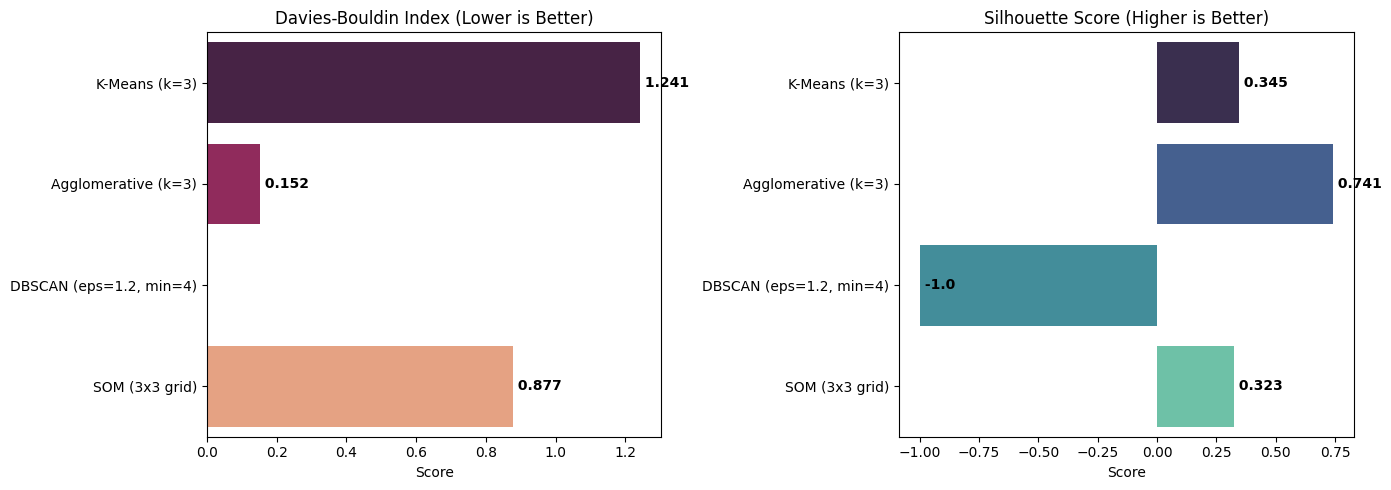


   CLUSTERING ALGORITHM MENU
1. View Dataset Preview
2. Apply K-Means
3. Apply Agglomerative Hierarchical
4. Apply DBSCAN
5. Apply Kohonen SOM
6. Run Model Comparison (All Models)
7. Back to Dataset Menu


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime as dt

warnings.filterwarnings('ignore')

def data_wholesale():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
    return pd.read_csv(url)

def data_retail():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    df = pd.read_excel(url)
    df = df.dropna(subset=['CustomerID'])
    df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
    max_date = df['InvoiceDate'].max()
    df['Recency'] = (max_date - df['InvoiceDate']).dt.days
    rfm = df.groupby('CustomerID').agg({
        'Recency': 'min',
        'InvoiceNo': 'nunique',
        'TotalPrice': 'sum'
    }).reset_index()
    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    rfm = rfm[(rfm['Monetary'] > 0) & (rfm['Frequency'] > 0)]
    return rfm

def scaler(X):
    return (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)

def kmeans(X, k, max_iters=100):
    np.random.seed(42)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    labels = np.zeros(X.shape[0])
    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[labels == i].mean(axis=0) if np.sum(labels == i) > 0 else centroids[i] for i in range(k)])
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return labels

def agglomerative_hierarchical(X, k):
    n = X.shape[0]
    clusters = {i: [i] for i in range(n)}
    while len(clusters) > k:
        keys = list(clusters.keys())
        min_dist = float('inf')
        merge_pair = (None, None)
        centroids = {c: np.mean(X[clusters[c]], axis=0) for c in keys}
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                d = np.linalg.norm(centroids[keys[i]] - centroids[keys[j]])
                if d < min_dist:
                    min_dist = d
                    merge_pair = (keys[i], keys[j])
        c1, c2 = merge_pair
        clusters[c1].extend(clusters[c2])
        del clusters[c2]
    labels = np.zeros(n, dtype=int)
    for cluster_idx, (key, pts) in enumerate(clusters.items()):
        for p in pts:
            labels[p] = cluster_idx
    return labels

def dbscan(X, eps, min_samples):
    n = X.shape[0]
    labels = np.full(n, -2)
    cluster_id = 0
    for p in range(n):
        if labels[p] != -2:
            continue
        neighbors = np.where(np.linalg.norm(X - X[p], axis=1) <= eps)[0]
        if len(neighbors) < min_samples:
            labels[p] = -1
        else:
            labels[p] = cluster_id
            i = 0
            neighbors = list(neighbors)
            while i < len(neighbors):
                q = neighbors[i]
                if labels[q] == -1:
                    labels[q] = cluster_id
                elif labels[q] == -2:
                    labels[q] = cluster_id
                    q_neighbors = np.where(np.linalg.norm(X - X[q], axis=1) <= eps)[0]
                    if len(q_neighbors) >= min_samples:
                        neighbors.extend(q_neighbors)
                i += 1
            cluster_id += 1
    return labels

def som(X, grid_x, grid_y, iters=100, lr=0.5):
    np.random.seed(42)
    radius = max(grid_x, grid_y) / 2.0
    weights = np.random.rand(grid_x, grid_y, X.shape[1])
    for i in range(iters):
        curr_lr = lr * (1 - i / iters)
        curr_rad = radius * (1 - i / iters)
        for x in X:
            dists = np.linalg.norm(weights - x, axis=2)
            bmu_x, bmu_y = np.unravel_index(np.argmin(dists, axis=None), dists.shape)
            for r in range(grid_x):
                for c in range(grid_y):
                    dist_to_bmu = np.sqrt((r - bmu_x)**2 + (c - bmu_y)**2)
                    if dist_to_bmu <= curr_rad:
                        inf = np.exp(-dist_to_bmu**2 / (2 * (curr_rad**2 + 1e-8)))
                        weights[r, c] += curr_lr * inf * (x - weights[r, c])
    labels = []
    for x in X:
        dists = np.linalg.norm(weights - x, axis=2)
        labels.append(np.argmin(dists))
    return np.array(labels)

def davies_bouldin_index(X, labels):
    valid_labels = set(labels) - {-1, -2}
    if len(valid_labels) < 2:
        return float('inf')

    centroids = []
    scatters = []

    for i in valid_labels:
        pts = X[labels == i]
        c = np.mean(pts, axis=0)
        s = np.mean(np.linalg.norm(pts - c, axis=1))
        centroids.append(c)
        scatters.append(s)

    db_sum = 0
    for i in range(len(centroids)):
        max_ratio = 0
        for j in range(len(centroids)):
            if i != j:
                dist = np.linalg.norm(centroids[i] - centroids[j])
                if dist > 0:
                    ratio = (scatters[i] + scatters[j]) / dist
                    if ratio > max_ratio:
                        max_ratio = ratio
        db_sum += max_ratio

    return round(db_sum / len(centroids), 3)

def silhouette_score_custom(X, labels):
    valid_labels = list(set(labels) - {-1, -2})
    if len(valid_labels) < 2:
        return -1.0

    mask = ~np.isin(labels, [-1, -2])
    X_valid = X[mask]
    labels_valid = labels[mask]
    n = X_valid.shape[0]

    if n > 2000:
        np.random.seed(42)
        indices = np.random.choice(n, 2000, replace=False)
        X_valid = X_valid[indices]
        labels_valid = labels_valid[indices]
        n = 2000

    s_vals = np.zeros(n)
    for i in range(n):
        p = X_valid[i]
        label_p = labels_valid[i]

        same_cluster = X_valid[labels_valid == label_p]
        if len(same_cluster) > 1:
            a_i = np.mean(np.linalg.norm(same_cluster - p, axis=1))
        else:
            a_i = 0

        b_i = float('inf')
        for other_label in valid_labels:
            if other_label != label_p:
                other_cluster = X_valid[labels_valid == other_label]
                if len(other_cluster) > 0:
                    dist = np.mean(np.linalg.norm(other_cluster - p, axis=1))
                    if dist < b_i:
                        b_i = dist

        if a_i == 0 and b_i == float('inf'):
            s_vals[i] = 0
        else:
            s_vals[i] = (b_i - a_i) / max(a_i, b_i)

    return round(np.mean(s_vals), 3)

def summarize_and_infer(df, label_col, features):
    print("\n--- Cluster Summary Table ---")
    summary = df.groupby(label_col)[features].mean().round(2)
    print(summary)

    print("\n--- Automated Inference ---")
    for feature in features:
        max_cluster = summary[feature].idxmax()
        min_cluster = summary[feature].idxmin()
        print(f"-> Cluster {max_cluster} represents the HIGHEST average {feature} ({summary.loc[max_cluster, feature]}).")
        print(f"-> Cluster {min_cluster} represents the LOWEST average {feature} ({summary.loc[min_cluster, feature]}).")
    print("-" * 50)

    plt.figure(figsize=(10, 6))
    sns.heatmap(summary, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
    plt.title(f"Cluster Feature Heatmap ({label_col})")
    plt.ylabel("Cluster ID")
    plt.xlabel("Features")
    plt.tight_layout()
    plt.show()

def plot_scatter(df, labels, title, x_col, y_col):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=x_col, y=y_col, hue=labels, palette='tab10', data=df, s=80, edgecolor='black', alpha=0.7)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def visualize_model_comparison(results_dict):
    models = list(results_dict.keys())
    dbi_scores = [res['DBI'] for res in results_dict.values()]
    sil_scores = [res['Silhouette'] for res in results_dict.values()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=dbi_scores, y=models, palette='rocket', ax=axes[0])
    axes[0].set_title("Davies-Bouldin Index (Lower is Better)")
    axes[0].set_xlabel("Score")
    for index, value in enumerate(dbi_scores):
        axes[0].text(value, index, f' {value}', va='center', fontweight='bold')

    sns.barplot(x=sil_scores, y=models, palette='mako', ax=axes[1])
    axes[1].set_title("Silhouette Score (Higher is Better)")
    axes[1].set_xlabel("Score")
    for index, value in enumerate(sil_scores):
        axes[1].text(value, index, f' {value}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

def process_clustering(df, available_features, x_col, y_col):
    print(f"\nAvailable features: {', '.join(available_features)}")
    selected = input("Enter features to cluster by (comma-separated), or press Enter to use all: ")

    if selected.strip():
        features = [f.strip() for f in selected.split(',') if f.strip() in available_features]
        if not features:
            print("No valid features selected. Defaulting to all.")
            features = available_features
    else:
        features = available_features

    print(f"\nClustering based on: {features}")
    scaled_data = scaler(df[features].values)

    while True:
        print("\n" + "="*40)
        print("   CLUSTERING ALGORITHM MENU")
        print("="*40)
        print("1. View Dataset Preview")
        print("2. Apply K-Means")
        print("3. Apply Agglomerative Hierarchical")
        print("4. Apply DBSCAN")
        print("5. Apply Kohonen SOM")
        print("6. Run Model Comparison (All Models)")
        print("7. Back to Dataset Menu")
        print("="*40)

        choice = input("Enter your choice: ")

        try:
            if choice == '1':
                print("\nDataset Preview:")
                print(df[features].head())
            elif choice == '2':
                k = int(input("Enter number of clusters: "))
                df['Cluster_KMeans'] = kmeans(scaled_data, k)
                summarize_and_infer(df, 'Cluster_KMeans', features)
                plot_scatter(df, df['Cluster_KMeans'], f'K-Means (k={k})', x_col, y_col)
            elif choice == '3':
                k = int(input("Enter number of clusters: "))
                df['Cluster_HC'] = agglomerative_hierarchical(scaled_data, k)
                summarize_and_infer(df, 'Cluster_HC', features)
                plot_scatter(df, df['Cluster_HC'], f'Agglomerative Hierarchical (k={k})', x_col, y_col)
            elif choice == '4':
                eps = float(input("Enter eps value (e.g., 1.5): "))
                min_samples = int(input("Enter min_samples (e.g., 5): "))
                df['Cluster_DBSCAN'] = dbscan(scaled_data, eps, min_samples)
                summarize_and_infer(df, 'Cluster_DBSCAN', features)
                plot_scatter(df, df['Cluster_DBSCAN'], f'DBSCAN (eps={eps}, min={min_samples})', x_col, y_col)
            elif choice == '5':
                x = int(input("Enter grid X dimension: "))
                y = int(input("Enter grid Y dimension: "))
                df['Cluster_SOM'] = som(scaled_data, x, y)
                summarize_and_infer(df, 'Cluster_SOM', features)
                plot_scatter(df, df['Cluster_SOM'], f'SOM ({x}x{y} grid)', x_col, y_col)
            elif choice == '6':
                print("\n--- Configure Model Comparison ---")
                k_val = int(input("Enter number of clusters (k) for K-Means and Agglomerative: "))
                eps_val = float(input("Enter eps value for DBSCAN (e.g., 1.5): "))
                min_samples_val = int(input("Enter min_samples for DBSCAN (e.g., 5): "))
                som_x = int(input("Enter grid X dimension for SOM: "))
                som_y = int(input("Enter grid Y dimension for SOM: "))

                print("\nRunning Model Comparison (This might take a moment)...")

                l_kmeans = kmeans(scaled_data, k_val)
                l_hc = agglomerative_hierarchical(scaled_data, k_val)
                l_dbscan = dbscan(scaled_data, eps=eps_val, min_samples=min_samples_val)
                l_som = som(scaled_data, som_x, som_y)

                results = {
                    f"K-Means (k={k_val})": {
                        "DBI": davies_bouldin_index(scaled_data, l_kmeans),
                        "Silhouette": silhouette_score_custom(scaled_data, l_kmeans)
                    },
                    f"Agglomerative (k={k_val})": {
                        "DBI": davies_bouldin_index(scaled_data, l_hc),
                        "Silhouette": silhouette_score_custom(scaled_data, l_hc)
                    },
                    f"DBSCAN (eps={eps_val}, min={min_samples_val})": {
                        "DBI": davies_bouldin_index(scaled_data, l_dbscan),
                        "Silhouette": silhouette_score_custom(scaled_data, l_dbscan)
                    },
                    f"SOM ({som_x}x{som_y} grid)": {
                        "DBI": davies_bouldin_index(scaled_data, l_som),
                        "Silhouette": silhouette_score_custom(scaled_data, l_som)
                    }
                }

                print("\n--- Model Comparison Results ---")
                print(f"{'Model':<35} | {'DBI (Lower is Better)':<25} | {'Silhouette (Higher is Better)'}")
                print("-" * 95)
                for model, scores in results.items():
                    print(f"{model:<35} | {scores['DBI']:<25} | {scores['Silhouette']}")
                print("-" * 95)

                visualize_model_comparison(results)

            elif choice == '7':
                break
            else:
                print("\nInvalid choice. Try again.")
        except Exception as e:
            print(f"\nAn error occurred: {e}. Please check your inputs.")

def main():
    try:
        while True:
            print("\n" + "="*40)
            print("   DATASET SELECTION MENU")
            print("="*40)
            print("1. Wholesale Customers Dataset")
            print("2. Online Retail Dataset (RFM Analysis)")
            print("3. Exit")
            print("="*40)

            choice = input("Select Dataset: ")

            if choice == '1':
                print("\nFetching Wholesale Data...")
                df = data_wholesale()
                features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
                process_clustering(df, features, 'Grocery', 'Milk')
            elif choice == '2':
                print("\nFetching & Processing Online Retail Data...")
                df = data_retail()
                features = ['Recency', 'Frequency', 'Monetary']
                process_clustering(df, features, 'Recency', 'Monetary')
            elif choice == '3':
                print("\nExiting...")
                break
            else:
                print("\nInvalid choice. Try again.")
    except KeyboardInterrupt:
        print("\n\nProgram interrupted by user. Exiting.")

if __name__ == "__main__":
    main()